# Data Extraction

In [464]:
# Run if dependencies not installed
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install pandas
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Extracting the Training and Test Data

In [465]:
import pandas as pd

train_df = pd.read_csv("../data/splits/train.csv")
test_df  = pd.read_csv("../data/splits/test_github.csv")

print("=" * 30)
print("TRAIN SET")
print("=" * 30)
print(f"Shape : {train_df.shape}\n")
print(f"Column names:\n{train_df.columns.tolist()}\n")
print(f"Data types:\n{train_df.dtypes}\n")
print(f"First 5 rows:\n{train_df.head()}\n")

print("=" * 30)
print("TARGET")
print("=" * 30)
print(train_df["readmitted"].value_counts())
print(train_df["readmitted"].value_counts(normalize=True))

TRAIN SET
Shape : (71236, 51)

Column names:
['id', 'encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:
id                          int64
encounter_id                int64
patient_nbr                 int64
race            

### Removing Dupicates from Data Set
There are no duplicates in the training data

In [466]:
import pandas as pd

print("=" *60)
num_duplicates  = train_df.duplicated().sum()
print(f"The train set contains: {num_duplicates } duplicates")
print("=" *60)

if (num_duplicates > 0):
    train_df = train_df.drop_duplicates()
    print(train_df.describe())

The train set contains: 0 duplicates


### Determining the Distribution of Training Data

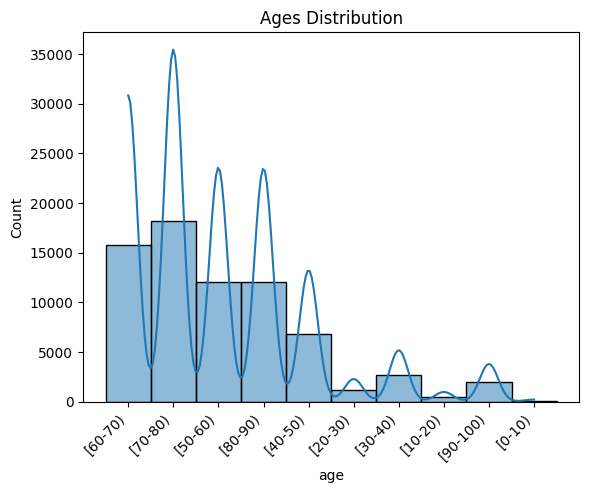

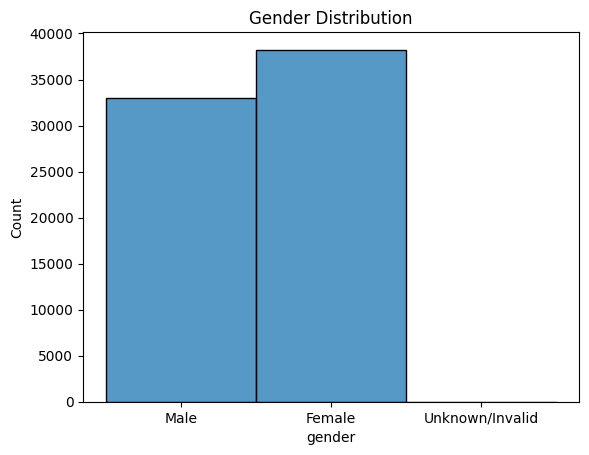

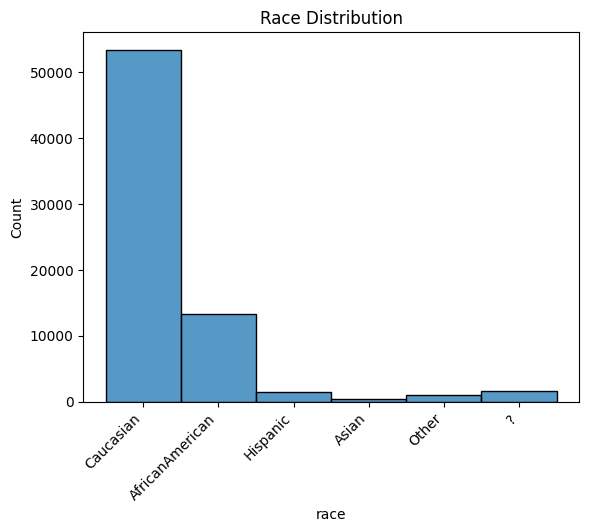

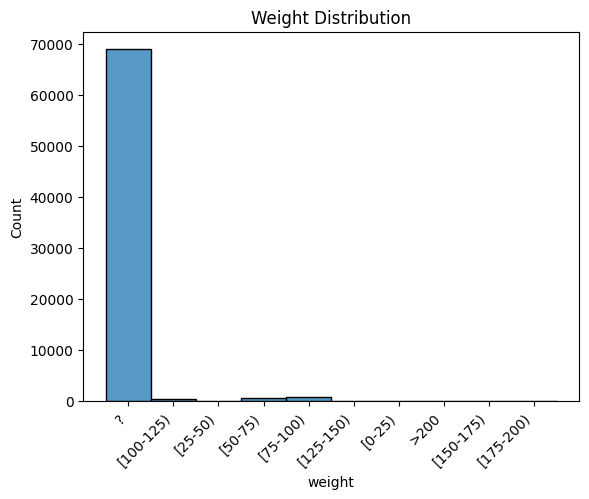

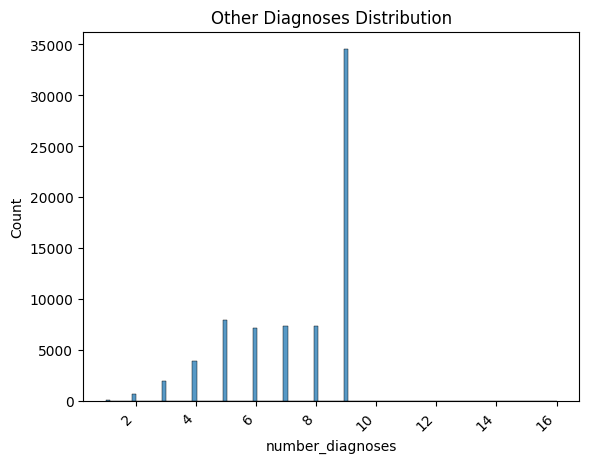

In [467]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.histplot(train_df.age, kde=True).set(title="Ages Distribution")
plt.xticks(rotation=45, ha='right')
plt.show()
sns.histplot(train_df.gender).set(title="Gender Distribution")
plt.show()
sns.histplot(train_df.race).set(title="Race Distribution")
plt.xticks(rotation=45, ha='right')
plt.show()
sns.histplot(train_df.weight).set(title="Weight Distribution")
plt.xticks(rotation=45, ha='right')
plt.show()
sns.histplot(train_df.number_diagnoses).set(title="Other Diagnoses Distribution")
plt.xticks(rotation=45, ha='right')
plt.show()


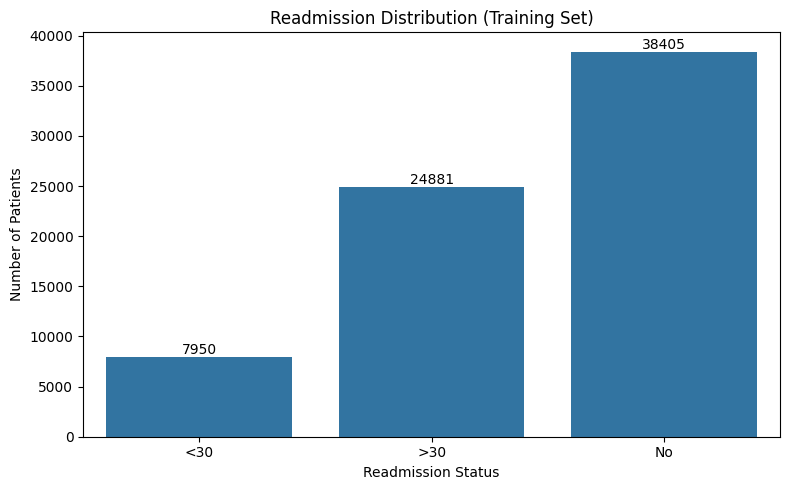

In [468]:
plt.figure(figsize=(8, 5))
train_df["readmitted"] = pd.Categorical(train_df["readmitted"], ["<30", ">30", "No"])

ax = sns.countplot(
    x="readmitted",
    data=train_df,
    order=["<30", ">30", "No"],
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Readmission Distribution (Training Set)")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [469]:
row_count = train_df.shape[0]
for feature in train_df:    
    count = (train_df[feature] == "?").sum()
    count += (train_df[feature].isnull()).sum()
    print(f"Missing value count [{feature}]: {count}, percentage: {round(count/row_count, 3)}%")

Missing value count [id]: 0, percentage: 0.0%
Missing value count [encounter_id]: 0, percentage: 0.0%
Missing value count [patient_nbr]: 0, percentage: 0.0%
Missing value count [race]: 1621, percentage: 0.023%
Missing value count [gender]: 0, percentage: 0.0%
Missing value count [age]: 0, percentage: 0.0%
Missing value count [weight]: 68986, percentage: 0.968%
Missing value count [admission_type_id]: 0, percentage: 0.0%
Missing value count [discharge_disposition_id]: 0, percentage: 0.0%
Missing value count [admission_source_id]: 0, percentage: 0.0%
Missing value count [time_in_hospital]: 0, percentage: 0.0%
Missing value count [payer_code]: 28178, percentage: 0.396%
Missing value count [medical_specialty]: 34930, percentage: 0.49%
Missing value count [num_lab_procedures]: 0, percentage: 0.0%
Missing value count [num_procedures]: 0, percentage: 0.0%
Missing value count [num_medications]: 0, percentage: 0.0%
Missing value count [number_outpatient]: 0, percentage: 0.0%
Missing value count

### Summary of Distributions

### Visulalizing Correlations

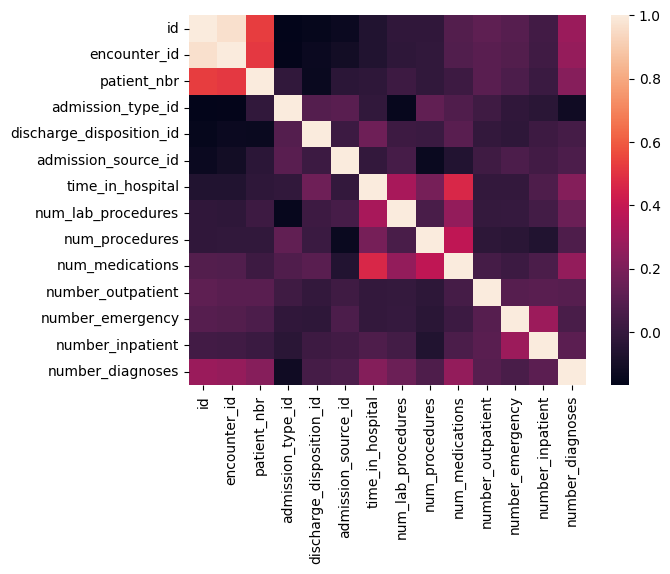

In [470]:
import pandas as pd
import seaborn as sns

#testign
numerics = train_df.select_dtypes(include="number")
correlation = train_df.corr(numeric_only=True)

plt.figure()

sns.heatmap(correlation)

plt.show()


This correlation plot does not tell us a lot and the reason for this is that a lot of the data in the training set is categorical. To extract some meaningful information we have to do some preprocessing of the data.

# Preprocessing pipeline

### Dropping uneccesarry columns

In [471]:
# Essentially these columns are just identifiers.
COLUMNS_TO_DROP = ["id", "encounter_id", "patient_nbr"]
train_df.drop(columns=COLUMNS_TO_DROP, inplace=True)
test_df.drop(columns=COLUMNS_TO_DROP, inplace=True)

In [472]:
# If a column contains more than THREASHOLD missing data then we will remove that column
THREASHOLD = 0.10 # In as a percentage so 0.10 is 10%
# The selected threshold of 10% is selected on the basis of this paper:
# https://www.sciencedirect.com/science/article/pii/S1326020023036488
# Which argues that a feature with more than 10% missing values can lead to bias


row_count = train_df.shape[0]
columns_with_missing_data = []

for feature in train_df:
    if feature == "readmitted":
        continue
    count = (train_df[feature] == "?").sum()
    count += (train_df[feature].isnull()).sum()
    percentage_missing = count/row_count
    if percentage_missing > THREASHOLD and feature != "A1Cresult":
        columns_with_missing_data.append(feature)

print(len(columns_with_missing_data))
train_df.drop(columns=columns_with_missing_data, inplace=True)
test_df.drop(columns=columns_with_missing_data, inplace=True)


4


In [473]:
# Reduce 3-class target to binary class
# The most clinically intressting is <30 so that is all patients readmitted within 30 days
# But with the assignment saying "patient that gets readmitted or not this would be more inline with the
# project description.
target = "readmitted"
train_df[target] = train_df[target].map(lambda x: 1 if x == '<30' or x == '>30' else 0)
test_df[target] = test_df[target].map(lambda x: 1 if x == '<30' or x == '>30' else 0)
print(train_df[target].value_counts())
print(train_df[target].unique())
print(train_df[target].sum()) 

readmitted
0    38405
1    32831
Name: count, dtype: int64
[0 1]
32831


### One-Hot-Encoding

['insulin_Down', 'insulin_No', 'insulin_Steady', 'insulin_Up']


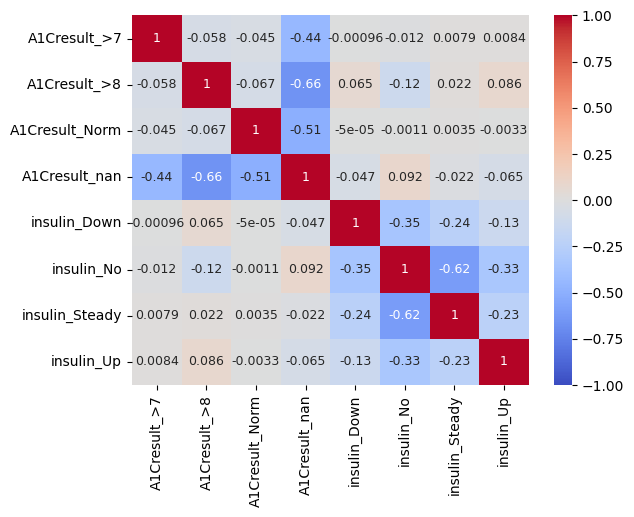

In [474]:
from sklearn import preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

enc = preprocessing.OneHotEncoder(handle_unknown="ignore", sparse_output=False)
test_enc = preprocessing.OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.set_output(transform="pandas")
test_enc.set_output(transform="pandas")
enc.fit(train_df)
test_enc.fit(test_df)

## plot code
encoded_df = enc.transform(train_df)
A1C_encode = [x for x in encoded_df if "A1C" in x]
medications = [x for x in encoded_df if "insulin" in x]
print(medications)
cols = A1C_encode + medications

encoded_normalized_arr = preprocessing.normalize(encoded_df)
encoded_normalized_df = pd.DataFrame(encoded_normalized_arr, columns=encoded_df.columns, index=encoded_df.index)

df_new = encoded_normalized_df[cols]
corr = df_new.corr()
plt.figure()
sns.heatmap(corr, vmin=-1, vmax=1, cmap="coolwarm", annot=True, annot_kws={"size": 9})
plt.show()

#### Summary of Plot Above

Barely any correlation, if any, between the A1C results and the insulin measurments

### Correlation Between Inpatient, Emergeny and Outpatient to Readmitted

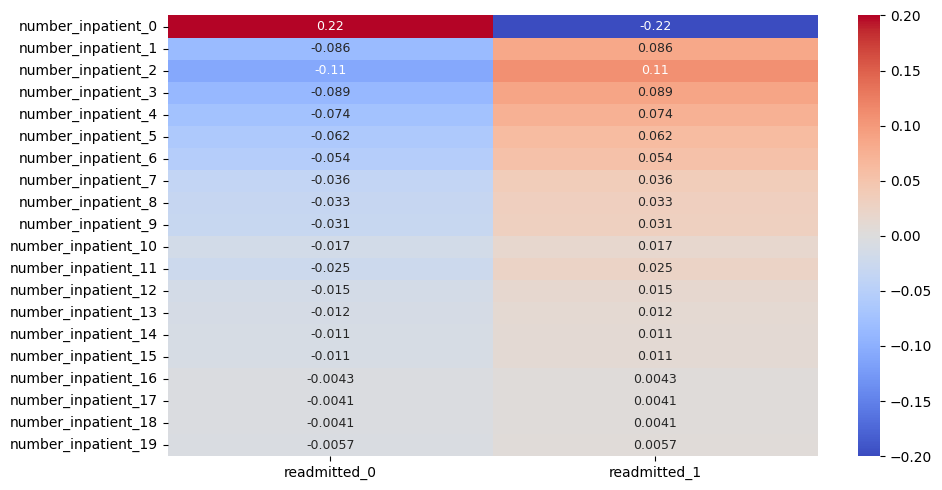

In [475]:
readmitted = [x for x in encoded_df if "readmitted" in x]
inpatients = [x for x in encoded_df if "inpatient" in x]
outpatients = [x for x in encoded_df if "outpatient" in x]
emergencies = [x for x in encoded_df if "emergency" in x]
time_in_hospital = [x for x in encoded_df if "time_in" in x]

feature_cols = inpatients + outpatients + emergencies + time_in_hospital
target_cols  = readmitted

corr_matrix = encoded_df[feature_cols + target_cols].corr()


# Get only feature -> readmitted correlations
corr_subset = corr_matrix.loc[inpatients, target_cols]

plt.figure(figsize=(10, 5))
sns.heatmap(corr_subset, vmin=-0.2, vmax=0.2, cmap="coolwarm", annot=True, annot_kws={"size": 9})
plt.tight_layout()
plt.show()


### Emergency $\to$ Readmitted

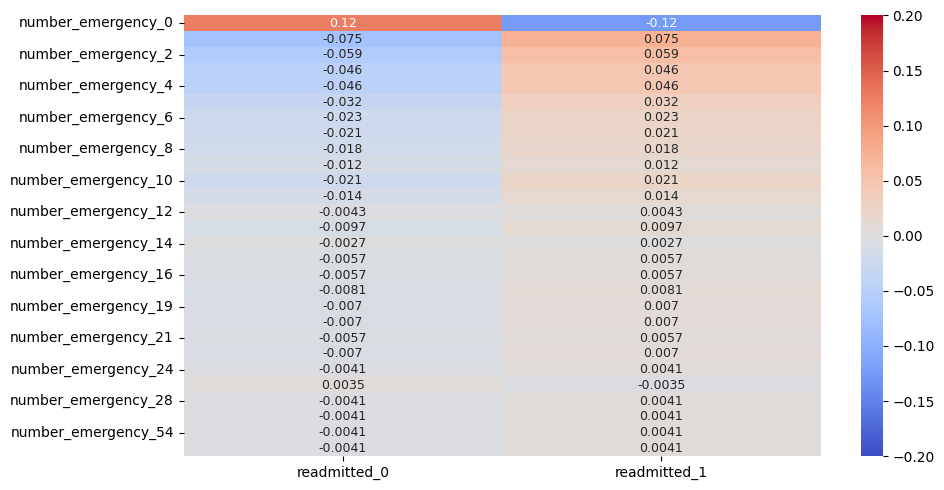

In [476]:
corr_subset = corr_matrix.loc[emergencies, target_cols]
plt.figure(figsize=(10, 5))
sns.heatmap(corr_subset, vmin=-0.2, vmax=0.2, cmap="coolwarm", annot=True, annot_kws={"size": 9})
plt.tight_layout()
plt.show()

### Number Outpatients $\to$ Readmitted

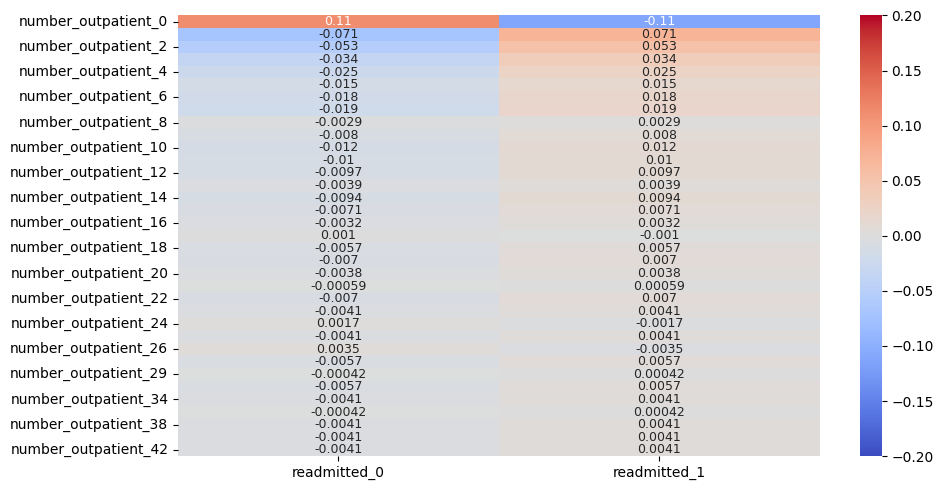

In [477]:
corr_subset = corr_matrix.loc[outpatients, target_cols]
plt.figure(figsize=(10, 5))
sns.heatmap(corr_subset, vmin=-0.2, vmax=0.2, cmap="coolwarm", annot=True, annot_kws={"size": 9})
plt.tight_layout()
plt.show()

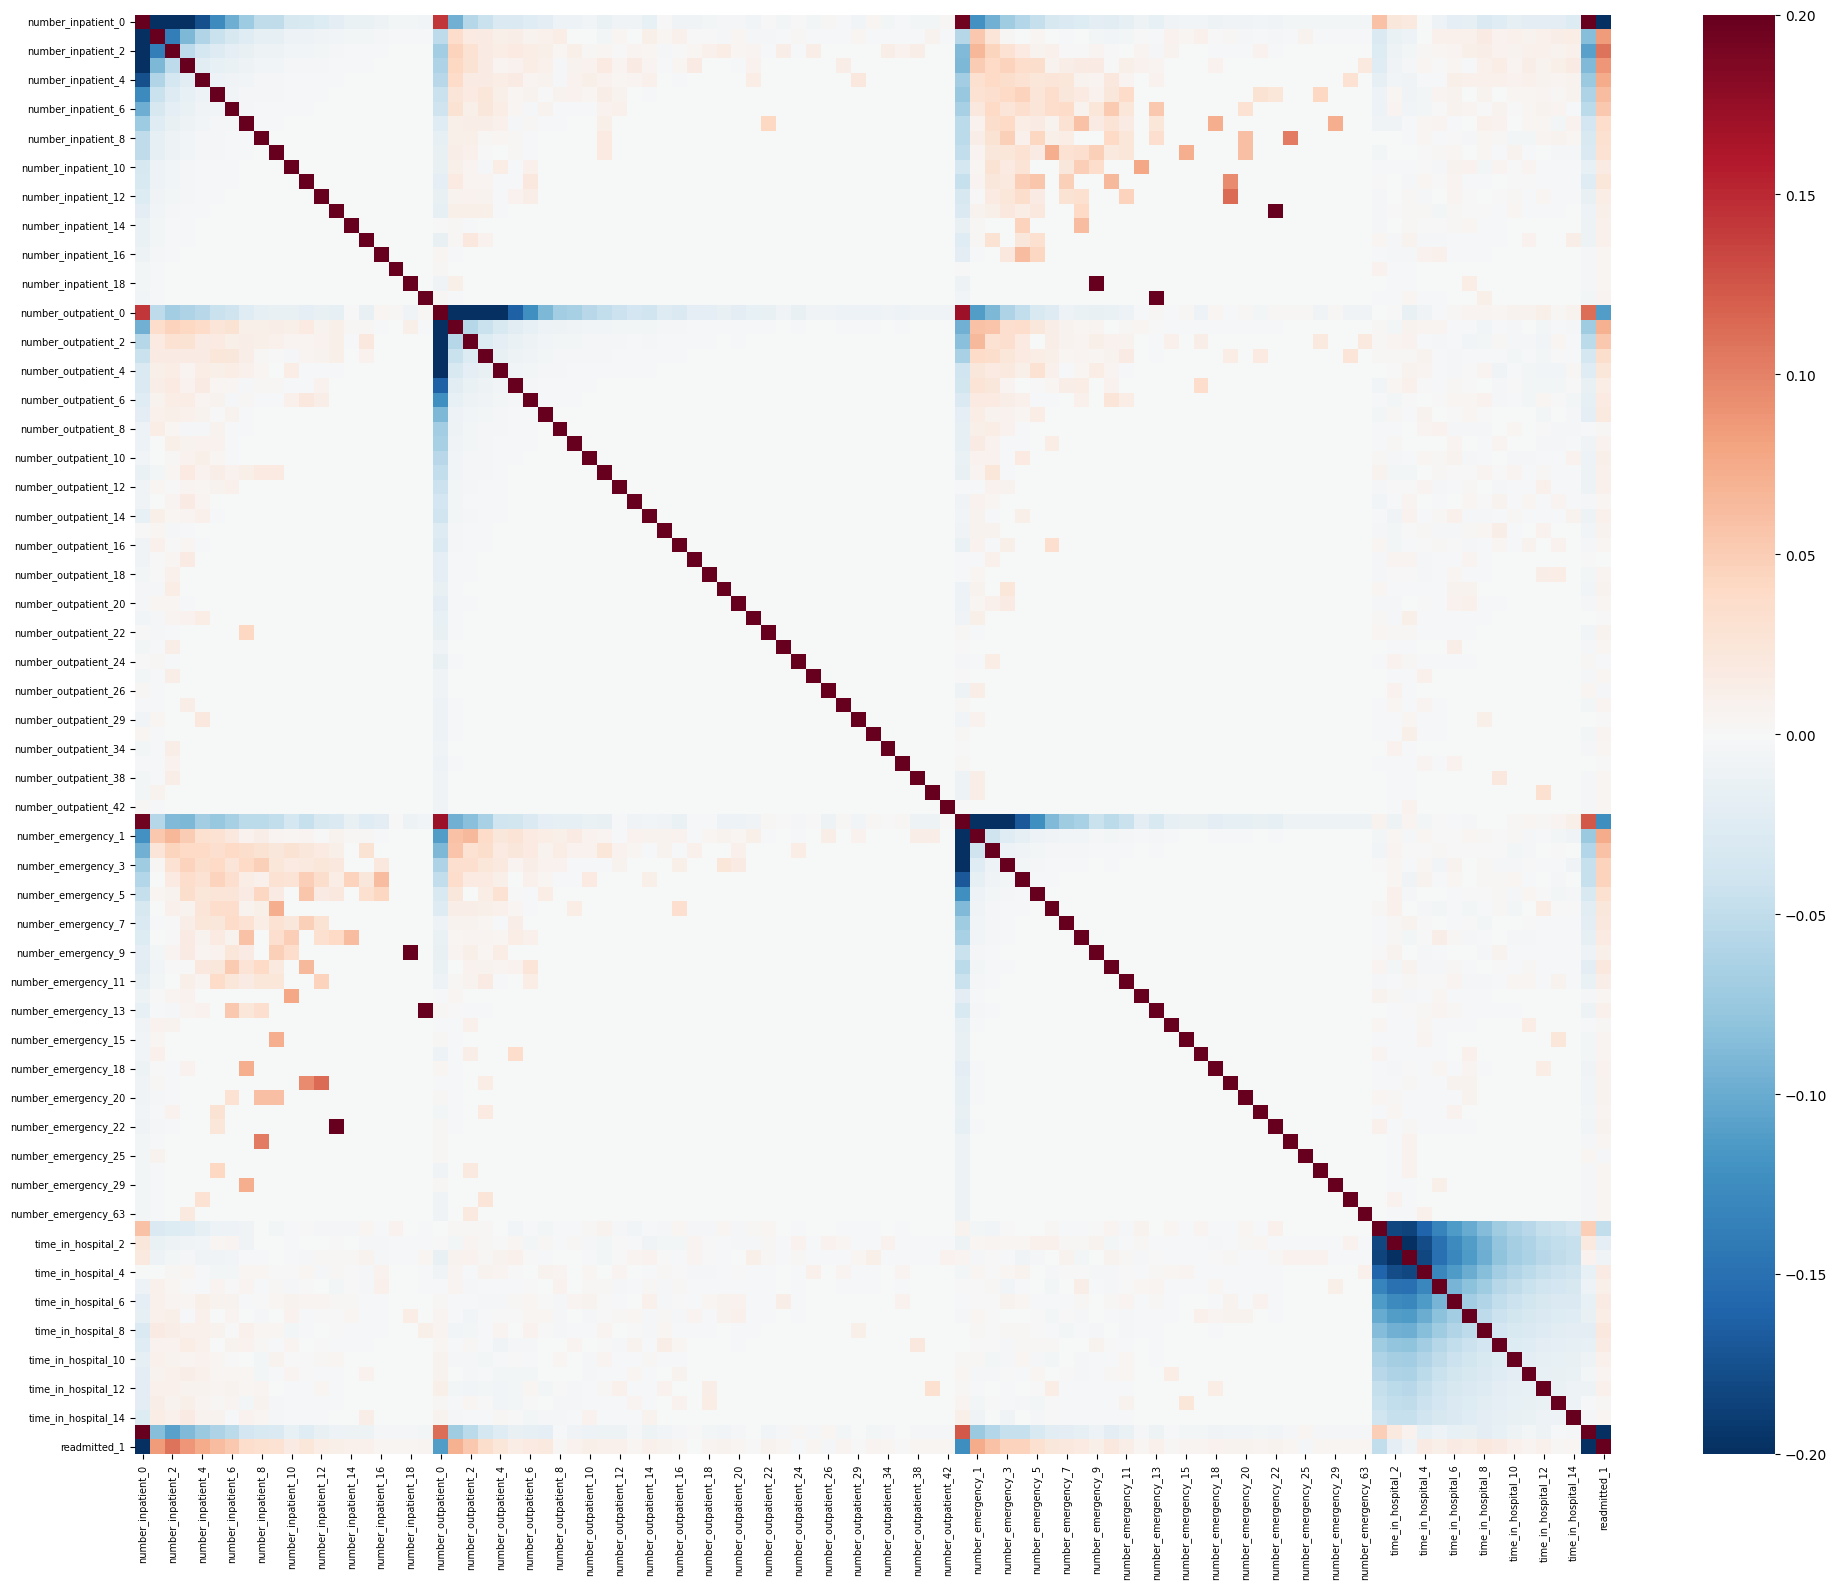

In [478]:
fig, ax = plt.subplots(figsize=(20, 16))  # much larger figure

sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',          # better diverging colormap
    center=0,
    vmin=-0.2, vmax=0.2,
    annot=False,             # drop numbers — too crowded
    linewidths=0,
    ax=ax
)

ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()

## Target Encoding

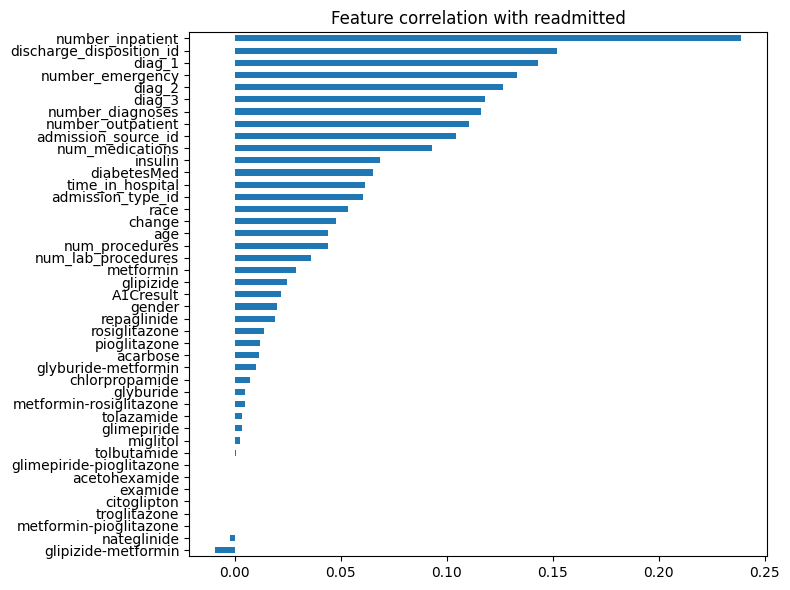

In [479]:
from sklearn import preprocessing
import pandas as pd

enc = preprocessing.TargetEncoder(smooth="auto")
enc.set_output(transform="pandas")

y = train_df["readmitted"]
y_test = test_df["readmitted"]
X = [x for x in train_df if x != "readmitted"]  
X_testing = [x for x in train_df if x != "readmitted"]  
X_trans = enc.fit_transform(train_df[X], y)
X_testing_trans = enc.fit_transform(test_df[X_testing], y_test)

X_trans["readmitted"] = y.values
X_testing_trans["readmitted"] = y_test.values
corr_with_target = X_trans.corr()["readmitted"].drop("readmitted").sort_values()

plt.figure(figsize=(8, 6))
corr_with_target.plot(kind="barh")
plt.title("Feature correlation with readmitted")
plt.tight_layout()
plt.show()

This shows a clear correlation between the number of inpatient exams someone had and if they were readmitted

### Filling in Missing Values Using kNN

In [480]:
from sklearn.impute import KNNImputer

X = X_trans
X_testing =X_testing_trans
imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputer.set_output(transform="pandas")
X_impute = imputer.fit_transform(X)
X_test_impute = imputer.fit_transform(X_testing)
print(X_impute.describe())

               race        gender           age  admission_type_id  \
count  71236.000000  71236.000000  71236.000000       71236.000000   
mean       0.460882      0.460873      0.460916           0.460877   
std        0.027464      0.010125      0.023829           0.030707   
min        0.300567      0.000000      0.172734           0.000000   
25%        0.461871      0.450696      0.442017           0.458590   
50%        0.468619      0.469112      0.467343           0.471159   
75%        0.469402      0.469667      0.478986           0.473172   
max        0.469833      0.471039      0.485046           0.542340   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count              71236.000000         71236.000000      71236.000000   
mean                   0.460867             0.460870          0.460869   
std                    0.077252             0.052643          0.032606   
min                    0.000000             0.000000          0.397041   

# Model Selection

### Naive Bayes (Gaussian)

In [481]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
X = X_impute.drop(columns=["readmitted"])
y = X_impute["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)

print("Number of mislabeled points out of a total %d points : %d"
    % (X_test.shape[0], (y_test != y_pred).sum()))



Number of mislabeled points out of a total 17809 points : 8737


### Computing the Accuracy

In [482]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_test, y_pred)
print(score)

0.5094053568420461


**Note**: This trains on all data. We could try dropping some features that doesn't have a strong correlation with readmitted

In [483]:
# small_corr = []
# for x in corr_with_target:
#     if x < 0.10:
#         small_corr.append(corr_with_target.index)

# print(small_corr)

small_corr = [feature for feature, corr in corr_with_target.items() if abs(corr) < 0.10]

print(f"Low-correlation features ({len(small_corr)}):")
print(small_corr)

new_X = X_impute.drop(columns=small_corr)
new_X_test = X_test_impute.drop(columns=small_corr)

Low-correlation features (34):
['glipizide-metformin', 'nateglinide', 'metformin-pioglitazone', 'troglitazone', 'citoglipton', 'examide', 'acetohexamide', 'glimepiride-pioglitazone', 'tolbutamide', 'miglitol', 'glimepiride', 'tolazamide', 'metformin-rosiglitazone', 'glyburide', 'chlorpropamide', 'glyburide-metformin', 'acarbose', 'pioglitazone', 'rosiglitazone', 'repaglinide', 'gender', 'A1Cresult', 'glipizide', 'metformin', 'num_lab_procedures', 'num_procedures', 'age', 'change', 'race', 'admission_type_id', 'time_in_hospital', 'diabetesMed', 'insulin', 'num_medications']


In [484]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
X = new_X.drop(columns="readmitted")
y = new_X["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)

print("Number of mislabeled points out of a total %d points : %d"
    % (X_test.shape[0], (y_test != y_pred).sum()))


Number of mislabeled points out of a total 17809 points : 6577


In [485]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_test, y_pred)
print(score)

0.6306923465663429


As we can see here, we can achived better accuracy whem dropping low correlation features!

### Random Forest

In [486]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_data = new_X.drop(columns="readmitted")
y_data = new_X["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.5, random_state=0, stratify=new_X["readmitted"]
)

clf = RandomForestClassifier(max_depth=10, random_state=0, n_estimators=100)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.65      0.73      0.69     19203
         1.0       0.63      0.54      0.58     16415

    accuracy                           0.64     35618
   macro avg       0.64      0.63      0.63     35618
weighted avg       0.64      0.64      0.64     35618



### Logistic Regression

In [487]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)
y_pred = model.predict(X_test)

model.score(X_test, y_test)
print(f"Accuracy: {score}")

Accuracy: 0.6306923465663429


### More Preprocessing and Dimension Reduction

In [488]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('clf', LogisticRegression())
])

pipe.fit(X_train, y_train)
pipe.predict(X_test)

print(f"score = {pipe.score(X_test, y_test)}")

score = 0.638918524341625


# Testing With test_github.csv

In [489]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import pandas as pd

y_test_data = X_test_impute["readmitted"]

X_test_data = new_X_test.drop(columns="readmitted")

pipe.score(X_test_data, y_test_data)




0.6325581395348837